In [29]:
import xarray as xr
import isku_utils
import cdsapi

import numpy as np
import geopandas as gpd
from scipy.stats import norm
import matplotlib.pyplot as plt

from dotenv import load_dotenv
import os

import analysis_utils
import isku_utils

import importlib

importlib.reload(analysis_utils)
importlib.reload(isku_utils)

load_dotenv()
DATA_DIR = os.environ["DATA_DIR"]

In [9]:
IMPACT_REGION_POLYGONS = os.environ["POREALLAS_REGIONS_POLYGONS_URI"]
SOCIOECONOMICS_URI = os.environ["POREALLAS_SOCIOECONOMICS_URI"]

In [11]:
# Impact Regions
_polygons = (
    gpd.read_parquet(os.path.join(DATA_DIR, IMPACT_REGION_POLYGONS))
    .rename(columns={"hierid": "region"})
    .set_index("region")
    .set_crs(epsg=4326)  # Assuming the data is WGS-82.
)

# Socioeconomics
socioeconomics = xr.open_zarr(os.path.join(DATA_DIR, SOCIOECONOMICS_URI))
socioeconomics = socioeconomics.sel(year=2026)[
    ["pop", "gdppc", "iso3"]
]

# API Data Download

In [ ]:
### Projection ###

dataset = "projections-climate-atlas"
request = {
    "origin": "cmip6",
    "experiment": "ssp2_4_5",
    "domain": "global",
    "period": "2015-2100",
    "variable": "monthly_mean_of_daily_mean_temperature",
}

client = cdsapi.Client()
client.retrieve(dataset, request, "./data/cmip6_2015_2100_monthly_tmean_ssp245.nc")

In [ ]:
### Historical ###
dataset = "projections-climate-atlas"
request = {
    "origin": "cmip6",
    "experiment": "historical",
    "domain": "global",
    "period": "1850-2014",
    "variable": "monthly_mean_of_daily_mean_temperature",
}

client = cdsapi.Client()
client.retrieve(dataset, request, "./data/cmip6_hist_1850_2014_monthly_tmean.nc")

In [ ]:
## Monthly Hindcast
import cdsapi

dataset = "seasonal-monthly-single-levels"
request = {
    "originating_centre": "ecmwf",
    "system": "51",
    "variable": ["2m_temperature"],
    "product_type": ["monthly_mean"],
    "year": [
        "1981",
        "1982",
        "1983",
        "1984",
        "1985",
        "1986",
        "1987",
        "1988",
        "1989",
        "1990",
        "1991",
        "1992",
        "1993",
        "1994",
        "1995",
        "1996",
        "1997",
        "1998",
        "1999",
        "2000",
        "2001",
        "2002",
        "2003",
        "2004",
        "2005",
        "2006",
        "2007",
        "2008",
        "2009",
        "2010",
        "2011",
        "2012",
        "2013",
        "2014",
    ],
    "month": ["07"],
    "leadtime_month": ["1", "2", "3", "4", "5", "6"],
    "data_format": "netcdf",
}

client = cdsapi.Client()
client.retrieve(dataset, request, "./data/seas5_1981_2014_monthly_tmean_2.nc")

In [ ]:
## Monthly Forecast
dataset = "seasonal-monthly-single-levels"
request = {
    "originating_centre": "ecmwf",
    "system": "51",
    "variable": ["2m_temperature"],
    "product_type": ["monthly_mean"],
    "year": ["2026"],
    "month": ["07"],
    "leadtime_month": ["1", "2", "3", "4", "5", "6"],
    "data_format": "netcdf",
}

client = cdsapi.Client()
client.retrieve(dataset, request, "./data/seas5_202607_monthly_tmean.nc")

# Data Processing

In [ ]:
import zipfile

with zipfile.ZipFile("./data/seas5_1981_2014_monthly_tmean_2.nc") as z:
    z.extractall("./data/")

In [ ]:
with zipfile.ZipFile("./data/seas5_1981_2014_monthly_tmean.nc") as z:
    print(z.namelist())

# Load Data

In [2]:
# Define Forecast Months
fc_months = [8, 9, 10, 11, 12, 1]

In [3]:
## CMIP6 Projections
ar6_project = xr.open_dataset(
    os.path.join(DATA_DIR, "t_CMIP6_ssp370_mon_201501-210012.nc"),
    chunks={"member": -1, "time": -1, "lat": 30, "lon": 30},
)
ar6_hist = xr.open_dataset(
    os.path.join(DATA_DIR, "t_CMIP6_historical_mon_185001-201412.nc"),
    chunks={"member": -1, "time": -1, "lat": 30, "lon": 30},
)

/home/emily_zuetell/projects/poreallas/.venv/lib/python3.14/site-packages/xarray/conventions.py:205: SerializationWarning: variable 't' has multiple fill values {np.float32(1.0384594e+34), np.float32(-1.7014118e+38)} defined, decoding all values to NaN.
  var = coder.decode(var, name=name)
/tmp/ipykernel_1526/1641687981.py:2: UserWarning: The specified chunks separate the stored chunks along dimension "lat" starting at index 30. This could degrade performance. Instead, consider rechunking after loading.
  ar6_project = xr.open_dataset(
/tmp/ipykernel_1526/1641687981.py:2: UserWarning: The specified chunks separate the stored chunks along dimension "lon" starting at index 30. This could degrade performance. Instead, consider rechunking after loading.
  ar6_project = xr.open_dataset(
/home/emily_zuetell/projects/poreallas/.venv/lib/python3.14/site-packages/xarray/conventions.py:205: SerializationWarning: variable 't' has multiple fill values {np.float32(1.0384594e+34), np.float32(-1.7014

In [4]:
# IPCC Recent Baseline Period 1995-2014
hist_mean = (
    ar6_hist["t"]
    .sel(time=slice("1995-01-01", "2014-12-31"))
    .groupby("time.month")
    .mean()
)
hist_mean = hist_mean.sel(month=fc_months).mean(dim="member").compute()

In [5]:
projection = ar6_project["t"]
projection = projection.assign_coords(
    year=projection.time.dt.year, month=projection.time.dt.month
)
projection = projection.set_index(time=["year", "month"]).unstack("time")
projection = projection.sel(month=fc_months).mean(dim=["member"]).compute()

In [6]:
### Seasonal Forecast ###
# Raw Forecast/Hindcast
s51 = xr.open_zarr(
    "/home/emily_zuetell/projects/poreallas/data/parsed/08_ecmwf_parsed.zarr"
)
forecast = (
    s51.sel(time=slice("2026-08-01", "2027-01-31"))
    .groupby("time.month")
    .mean()
    .compute()
)
hindcast = (
    s51.sel(time=slice("1995-08-01", "2014-01-31"))
    .groupby("time.month")
    .mean()
    .sel(month=[1, 8, 9, 10, 11, 12])
    .mean(dim="number")
    .compute()
)

# Empirical - Decade Basis

In [7]:
## Clean statistics
projection = projection.interpolate_na(dim="lat", method="linear")
hist_mean = hist_mean.interpolate_na(dim="lat", method="linear")
## Statistics ##
# Climate Projection: Get "annual 6-month anomaly"
mean_proj = projection.mean(dim="month")
mean_base = hist_mean.mean(dim="month")

anomaly_proj = mean_proj - mean_base
# Rolling avg
anomaly_proj_smooth = anomaly_proj.rolling(year=10, center=False, min_periods=10).mean()

ds1 = anomaly_proj_smooth
decade1 = ((ds1["year"] // 10) * 10).rename("decade")
# Enforce monotonically increasing projection
decade_min = ds1.groupby(decade1).min()
decade_max = ds1.groupby(decade1).max().cumulative("decade").max()
#decade_min = ds1.groupby(decade1).min()
decade_max_nc = ds1.groupby(decade1).max()

In [8]:
ds2 = forecast["tas"] - hindcast["tas"]
ds2 = ds2.mean(dim="month")
ds2 = isku_utils.lon_adjust(ds2, roll=True)

in_range = (ds2 >= (decade_min)) & (ds2 <= (decade_max))
below = ds2 < decade_min.min("decade")
above = ds2 > decade_max.max("decade")

mode_decade = in_range.where(in_range).idxmin("decade").compute()

da = xr.where(below, 2010, xr.where(above, 2110, mode_decade)).compute()

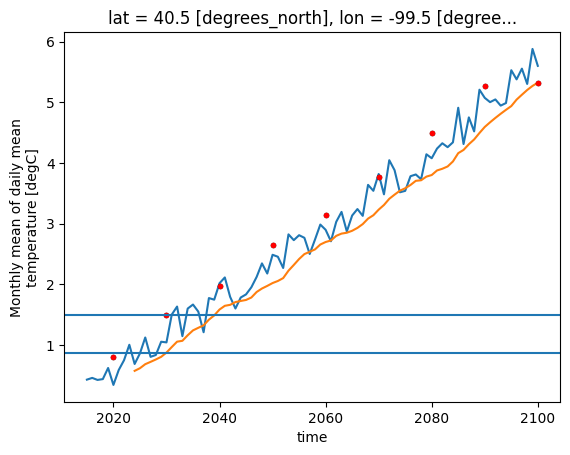

In [9]:
anomaly_proj.sel(lat = 40, lon = -100, method = 'nearest').plot()
anomaly_proj_smooth.sel(lat = 40, lon = -100, method = 'nearest').plot()
decade_max.sel(lat = 40, lon = -100, method = 'nearest').rename({'decade': "year"}).plot(linestyle = "", marker = 'o', markersize = 3, color = 'k')
decade_max_nc.sel(lat = 40, lon = -100, method = 'nearest').rename({'decade': "year"}).plot(linestyle = "", marker = 'o', markersize = 3, color = 'red')

plt.axhline(anomaly_proj_smooth.sel(lat = 40, lon = -100, method = 'nearest').sel(year = slice(2030, 2039)).min().values)
plt.axhline(anomaly_proj_smooth.sel(lat = 40, lon = -100, method = 'nearest').sel(year = slice(2030, 2039)).max().values)

In [ ]:
from scipy import stats

# Ensemble Stats
median = da.median(dim="number")


mode = xr.apply_ufunc(
    lambda x: stats.mode(x, axis=-1, keepdims=False).mode,
    da,
    input_core_dims=[["number"]],
    vectorize=True,
)
mode_count = xr.apply_ufunc(
    lambda x: stats.mode(x, axis=-1, keepdims=False).count,
    da,
    input_core_dims=[["number"]],
    vectorize=True,
)

In [12]:
mean = da.mean(dim = "number")

# Final Data

In [13]:
# Log forecast anomaly
fc_anomaly = isku_utils.grid_to_ir(ds2).mean(dim = 'number')
fc_anomaly_df = analysis_utils.xarray_to_gpd(fc_anomaly, _polygons)
fc_anomaly_df["value"].to_csv("2608_fc_anomaly.csv")

/home/emily_zuetell/projects/poreallas/analysis/isku_utils.py:29: RuntimeWarning: Failed to open Zarr store with consolidated metadata, but successfully read with non-consolidated metadata. This is typically much slower for opening a dataset. To silence this warning, consider:
1. Consolidating metadata in this existing store with zarr.consolidate_metadata().
2. Explicitly setting consolidated=False, to avoid trying to read consolidate metadata, or
3. Explicitly setting consolidated=True, to raise an error in this case instead of falling back to try reading non-consolidated metadata.
  _region_weights = xr.load_dataset(uri)[
/home/emily_zuetell/projects/poreallas/.venv/lib/python3.14/site-packages/zarr/core/group.py:3289: ZarrUserWarning: Object at zarr.json:Zone.Identifier is not recognized as a component of a Zarr hierarchy.
  warnings.warn(


In [31]:
fc_land = analysis_utils.land_only((forecast - hindcast), lat_name="latitude", lon_name="longitude")
fc_land_mean = analysis_utils.compute_area_weighted_mean(fc_land, lat_name="lat", lon_name="lon")

In [45]:
fc_ir = isku_utils.grid_to_ir((forecast - hindcast)['tas'])
merged_fc = xr.merge([fc_ir.rename('anomaly'), socioeconomics])
pop_weighted_fc = (merged_fc['anomaly'] * merged_fc['pop']).sum(dim='region') / merged_fc['pop'].sum(dim='region')

/home/emily_zuetell/projects/poreallas/analysis/isku_utils.py:29: RuntimeWarning: Failed to open Zarr store with consolidated metadata, but successfully read with non-consolidated metadata. This is typically much slower for opening a dataset. To silence this warning, consider:
1. Consolidating metadata in this existing store with zarr.consolidate_metadata().
2. Explicitly setting consolidated=False, to avoid trying to read consolidate metadata, or
3. Explicitly setting consolidated=True, to raise an error in this case instead of falling back to try reading non-consolidated metadata.
  _region_weights = xr.load_dataset(uri)[
/home/emily_zuetell/projects/poreallas/.venv/lib/python3.14/site-packages/zarr/core/group.py:3289: ZarrUserWarning: Object at zarr.json:Zone.Identifier is not recognized as a component of a Zarr hierarchy.
  warnings.warn(


/tmp/ipykernel_1526/4057680195.py:18: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


Text(0.5, 1.0, '')

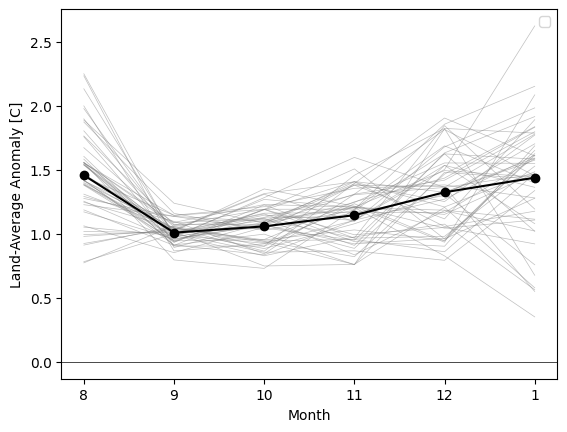

In [54]:
month_order = [8, 9, 10, 11, 12, 1]

fig, ax = plt.subplots()

da = fc_land_mean
da = da.assign_coords(
    month=range(len(month_order))
)  # 0..5 positions instead of real month values

da['tas'].plot.line(x = 'month', color = 'gray', linewidth = 0.5, alpha = 0.5, ax=ax)
da.mean(dim = 'number')['tas'].plot(marker="o", color = 'black', ax=ax)

ax.axhline(y=0, color="black", linewidth=0.5)
ax.set_xticks(range(len(month_order)))
ax.set_xticklabels(month_order)
ax.set_xlabel("Month")
ax.set_ylabel("Land-Average Anomaly [C]")
ax.legend()
ax.set_title("")

/tmp/ipykernel_1526/1271868102.py:18: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


Text(0.5, 1.0, '')

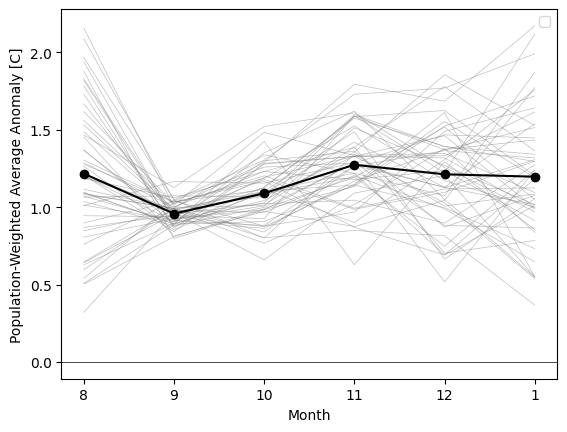

In [53]:
month_order = [8, 9, 10, 11, 12, 1]

fig, ax = plt.subplots()

da = pop_weighted_fc
da = da.assign_coords(
    month=range(len(month_order))
)  # 0..5 positions instead of real month values

da.plot.line(x = 'month', color = 'gray', linewidth = 0.5, alpha = 0.5, ax=ax)
da.mean(dim = 'number').plot(marker="o", color = 'black', ax=ax)

ax.axhline(y=0, color="black", linewidth=0.5)
ax.set_xticks(range(len(month_order)))
ax.set_xticklabels(month_order)
ax.set_xlabel("Month")
ax.set_ylabel("Population-Weighted Average Anomaly [C]")
ax.legend()
ax.set_title("")

In [14]:
data_ir_mean = isku_utils.grid_to_ir(mean)

/home/emily_zuetell/projects/poreallas/analysis/isku_utils.py:29: RuntimeWarning: Failed to open Zarr store with consolidated metadata, but successfully read with non-consolidated metadata. This is typically much slower for opening a dataset. To silence this warning, consider:
1. Consolidating metadata in this existing store with zarr.consolidate_metadata().
2. Explicitly setting consolidated=False, to avoid trying to read consolidate metadata, or
3. Explicitly setting consolidated=True, to raise an error in this case instead of falling back to try reading non-consolidated metadata.
  _region_weights = xr.load_dataset(uri)[
/home/emily_zuetell/projects/poreallas/.venv/lib/python3.14/site-packages/zarr/core/group.py:3289: ZarrUserWarning: Object at zarr.json:Zone.Identifier is not recognized as a component of a Zarr hierarchy.
  warnings.warn(


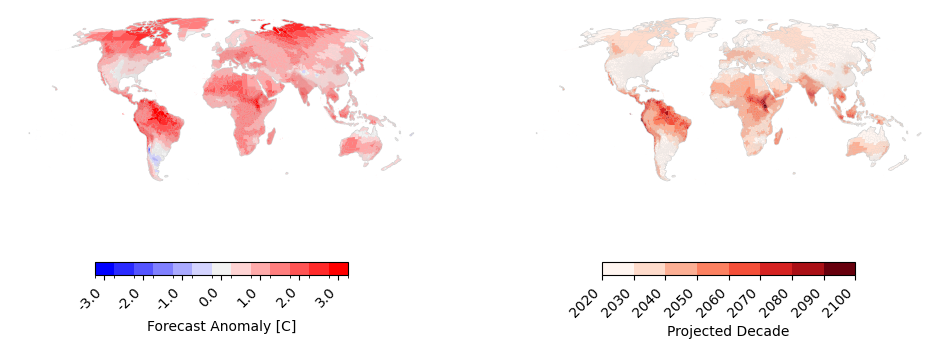

In [15]:
_polygons_postcard_mean = analysis_utils.xarray_to_gpd(data_ir_mean, _polygons)

fig, axs = plt.subplots(1, 2, figsize=(12, 6))
analysis_utils.plot_single(
    _polygons_postcard_mean,
    col="value",
    cm="Reds",
    vmin=2020,
    vmax=2100,
    cbar_label="Projected Decade",
    ax=axs[1],
    cbar_location="bottom",
)

analysis_utils.plot_single(
    fc_anomaly_df,
    col="value",
    cm="bwr",
    n_colors=13,
    cbar_label="Forecast Anomaly [C]",
    ax=axs[0],
    cbar_location="bottom",
)

fig.savefig("2608_combined_anomaly_postcard", dpi=600, bbox_inches="tight")

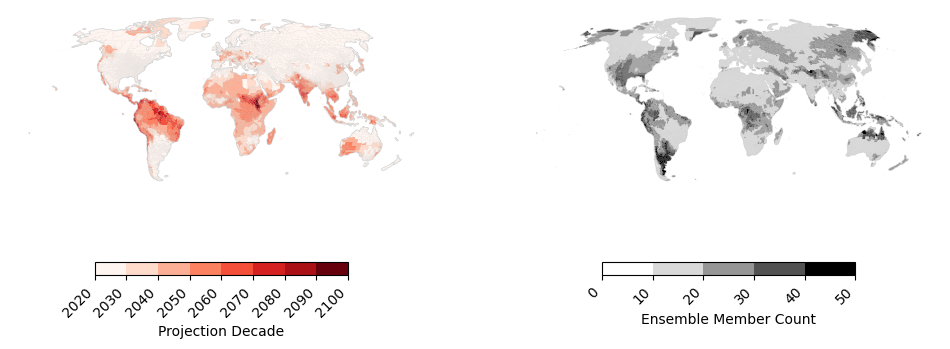

In [25]:
_polygons_postcard_mode = analysis_utils.xarray_to_gpd(data_ir_mode, _polygons)
_polygons_postcard_count = analysis_utils.xarray_to_gpd(data_ir_counts, _polygons)

fig, axs = plt.subplots(1, 2, figsize=(12, 6))
analysis_utils.plot_single(
    _polygons_postcard_mode,
    col="value",
    cm="Reds",
    vmin=2020,
    vmax=2100,
    cbar_label="Projection Decade",
    ax=axs[0],
    cbar_location="bottom",
)

analysis_utils.plot_single(
    _polygons_postcard_count,
    col="value",
    cm="Grays",
    vmin=0,
    vmax=50,
    cbar_label="Ensemble Member Count",
    ax=axs[1],
    cbar_location="bottom",
)

fig.savefig("2608_combined_spread_postcard", dpi=600, bbox_inches="tight")